In [92]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:
import logging
import os
from functools import partial

import matplotlib.pyplot as plt  # type: ignore
import numpy as np
from joblib import Parallel, delayed
from pixell import curvedsky
from tqdm.auto import tqdm

from scripts import core, Core
from scripts.utils import (
    remove_mono_dipole,
    setup_logging,
    plot_cl_alm,
    plot_patches,
    plot_predictions,
)

from notebooks.ksw_joblib import KSW_joblib

# Monkey patch the core module
core.KSW = KSW_joblib

In [94]:
logger = setup_logging(__name__, level=logging.DEBUG)

## Setup

In [95]:
core = Core(
    [
        "settings/heidelberg.json",
        "--nsims",
        "3",
        "--narray",
        "1",
        "--no-lensing",
        # "--polarizations",
        # "TE",
    ]
)

24-May-24 16:39:58 - scripts.core - DEBUG - Parsing CLI args: ['settings/heidelberg.json', '--nsims', '3', '--narray', '1', '--no-lensing']
24-May-24 16:39:58 - scripts.core - INFO - Loading settings from file settings/heidelberg.json
24-May-24 16:39:58 - scripts.core - DEBUG - Forcing setting 'nsims' to '3' due to CLI
24-May-24 16:39:58 - scripts.core - DEBUG - Forcing setting 'narray' to '1' due to CLI
24-May-24 16:39:58 - scripts.core - DEBUG - Forcing setting 'lensing' to 'False' due to CLI
24-May-24 16:39:58 - scripts.core - DEBUG - Found non-default value for 'cosmo_params': {'H0': 70.1, 'As': 2.457e-09, 'pivot_scalar': 0.002, 'ns': 0.96, 'ombh2': 0.02256, 'omch2': 0.1143, 'tau': 0.084, 'max_l': 1500, 'lmax': 1024} (default: {'As': 2.13e-09, 'ns': 0.9624, 'pivot_scalar': 0.05, 'max_l': 1000, 'lmax': 500})
24-May-24 16:39:58 - scripts.core - DEBUG - Overriding cosmo param As from 2.13e-09 to 2.457e-09
24-May-24 16:39:58 - scripts.core - DEBUG - Overriding cosmo param ns from 0.962

24-May-24 16:40:20 - scripts.core - DEBUG - Setting up data and KSW
24-May-24 16:40:20 - scripts.core - INFO - beam (1, 1025), noise (1, 1025), pols ['T'], npols 1
24-May-24 16:40:20 - notebooks.ksw_joblib - INFO - Using KSW_joblib
24-May-24 16:40:20 - scripts.core - DEBUG - done with KSW
24-May-24 16:40:20 - scripts.core - DEBUG - Setting 'patch_side_deg' not found, using default: 10
24-May-24 16:40:20 - scripts.core - DEBUG - Found non-default value for 'npatches': 10 (default: 2)
24-May-24 16:40:20 - scripts.core - DEBUG - Setting 'base_dir' not found, using default: 'data'
24-May-24 16:40:20 - scripts.core - DEBUG - Found non-default value for 'base_name': 'heidelberg' (default: 'l1024_n512_ul_T')
24-May-24 16:40:20 - scripts.core - INFO - Base name: heidelbergx3
24-May-24 16:40:20 - scripts.core - DEBUG - Setting 'plot_dir' not found, using default: 'plots'
24-May-24 16:40:20 - scripts.core - DEBUG - Setting 'tb_dir' not found, using default: 'tensorboard'
24-May-24 16:40:20 - scr

## Alm

This code generates the alms

$$a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}^{NG}$$
with
$$a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]$$
and
$$\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)$$
$$\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)$$
$$B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}$$
where $\Delta_\phi$ is primordial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions   

In [96]:
from scripts.almgen import generate_alm_ng

In [97]:
alm_l = np.array(
    [core.data.compute_alm_sim(core.lensing) for _ in range(core.nsims)],
    dtype=core.c_dtype,
)

fnls = core.rng.uniform(core.fnl_min, core.fnl_max, core.fnl_shape)

alm_ng = generate_alm_ng(core, alm_l)

alms = alm_l + fnls[:, None, :] * alm_ng
alms = remove_mono_dipole(alms)

24-May-24 16:40:37 - scripts.almgen - INFO - Starting Alm_ng generation
24-May-24 16:40:37 - scripts.almgen - DEBUG - Using temp folder for Alm_ng generation: /lustre/scratch/client/users/stevensonb


Alm_ng:   0%|          | 0/3 [00:00<?, ?it/s]

/lustre/work/client/users/stevensonb/.conda/envs/mlpng/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


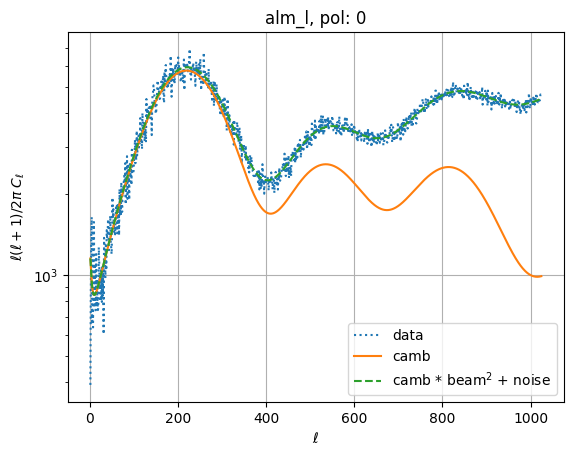

In [98]:
for pol in range(core.npol):
    plot_cl_alm(
        alm_l[0, pol],
        title=f"alm_l, pol: {pol}",
        plot_camb=True,
        c_ells=core.c_ells[:, pol],
        camb_noise=True,
        noise=core.noise_ell[pol],
        beam_width=core.beam_width,
    )

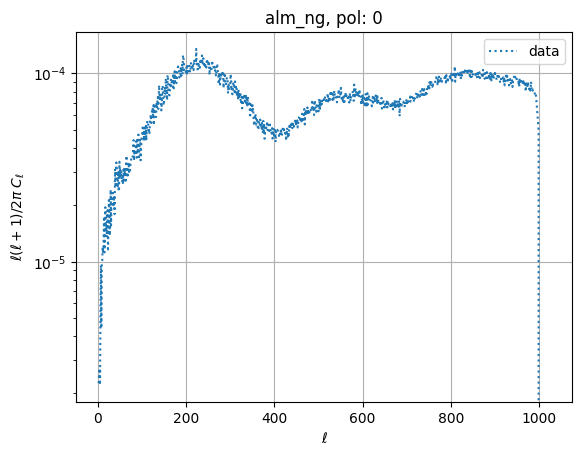

In [99]:
for pol in range(core.npol):
    plot_cl_alm(alm_ng[0, pol], title=f"alm_ng, pol: {pol}")

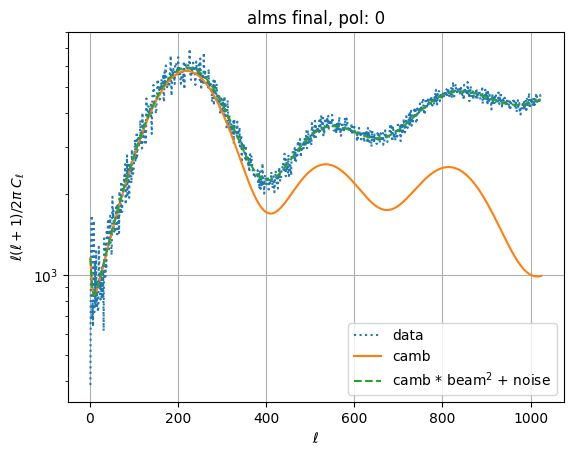

In [100]:
for pol in range(core.npol):
    plot_cl_alm(
        alms[0, pol],
        title=f"alms final, pol: {pol}",
        plot_camb=True,
        c_ells=core.c_ells[:, pol],
        camb_noise=True,
        noise=core.noise_ell[pol],
        beam_width=core.beam_width,
    )

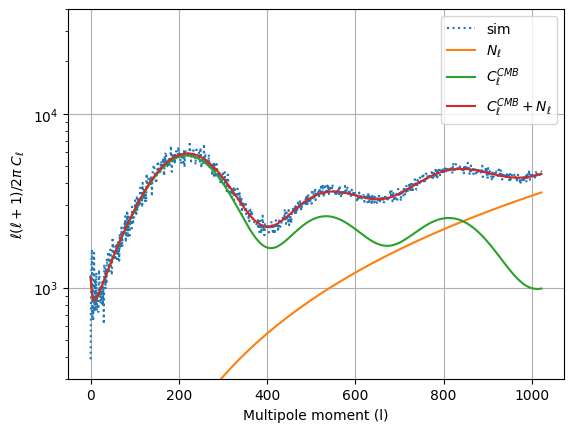

In [101]:
for pol in range(core.npol):
    ells = np.arange(2, core.nell)
    scale = ells * (ells + 1) / 2 / np.pi
    N_ell = core.noise_ell[pol, 2:]
    cl_cmb = core.c_ells[2 : core.nell, pol]
    cl_sim = curvedsky.alm2cl(alms[0, pol])[2 : core.nell]
    beam = core.beam_ell[pol, 2:]

    plot_func = plt.semilogy
    plot_func(scale * cl_sim, label=r"sim", linestyle=":")
    plot_func(scale * N_ell, label=r"$N_\ell$")
    plot_func(scale * cl_cmb, label=r"$C_{\ell}^{CMB}$")
    plot_func(scale * (cl_cmb * beam**2 + N_ell), label=r"$C_\ell^{CMB} + N_\ell$")

    plt.legend()
    plt.xlabel("Multipole moment (l)")
    plt.ylabel(r"$\ell(\ell+1)/2\pi\;C_{\ell}$")
    plt.grid(True)
    if pol == 0:
        plt.ylim([3e2, 4e4])
    if pol == 1:
        plt.ylim([1e-3, 1e2])
    plt.show()

## PatchGen

In [102]:
from scripts.patchgen import cutSqPatches_lenspyx, cutSqPatches_pixell, get_fs_patch_geo

In [104]:
# Here we get the geometry of our patches in a tuple
patch_geo = get_fs_patch_geo(core)

# We use joblib.parallel to generate the patches in parallel
# by default (temp_folder=None) this will use a ram disk /dev/shm
# if the data files are larger than the available memory, about 1TB, it will error
# so we give it a temp folder to use, which wont have that problem
temp_folder = os.environ.get("SCRATCH", None)
logger.debug(f"Using temp folder for patch generation: {temp_folder}")
parallel = Parallel(n_jobs=1, return_as="generator", temp_folder=temp_folder)

# we also setup the cutPatches function to use either pixell or lenspyx
# depending on if we are doing lensing or not, and provide a lot of
# arguments that are needed and will stay constant
# we cannot abuse the python scope here since these will need to be pickled
common_settings = [
    core.lmax,
    core.plot_dir,
    core.base_name,
    core.npatches,
    core.c_ells,
    *patch_geo,
]
if core.lensing:
    max_l = core.cosmo_params["max_l"]
    cl_phi = core.cosmo._camb_data.get_lens_potential_cls(  # type: ignore
        max_l, CMB_unit="muK", raw_cl=True
    )

    cutPatches = partial(
        cutSqPatches_lenspyx, *common_settings, max_l, core.nside, core.r_dtype
    )

    patch_generator = parallel(
        delayed(cutPatches)(alms[sim], fnls[sim], cl_phi[:, 0], True)
        for sim in range(core.nsims)
    )  # CL_PHI is in PP, PT, PE order, we only use the PP
else:
    cutPatches = partial(cutSqPatches_pixell, *common_settings)

    patch_generator = parallel(
        delayed(cutPatches)(alms[sim], fnls[sim], False) for sim in range(core.nsims)
    )

# create the array to store the patches
patches = np.empty(core.patch_shape, dtype=core.r_dtype)

# Get our data from the generator
for idx, result in enumerate(
    tqdm(patch_generator, desc="patch progress", total=core.nsims)
):
    patches[idx] = result

24-May-24 16:44:51 - __main__ - DEBUG - Using temp folder for patch generation: /lustre/scratch/client/users/stevensonb


patch progress:   0%|          | 0/3 [00:00<?, ?it/s]

24-May-24 16:44:51 - scripts.patchgen - DEBUG - (1, 525825), (1, 9217, 18432)
24-May-24 16:44:54 - scripts.patchgen - DEBUG - (1, 525825), (1, 9217, 18432)
24-May-24 16:44:58 - scripts.patchgen - DEBUG - (1, 525825), (1, 9217, 18432)


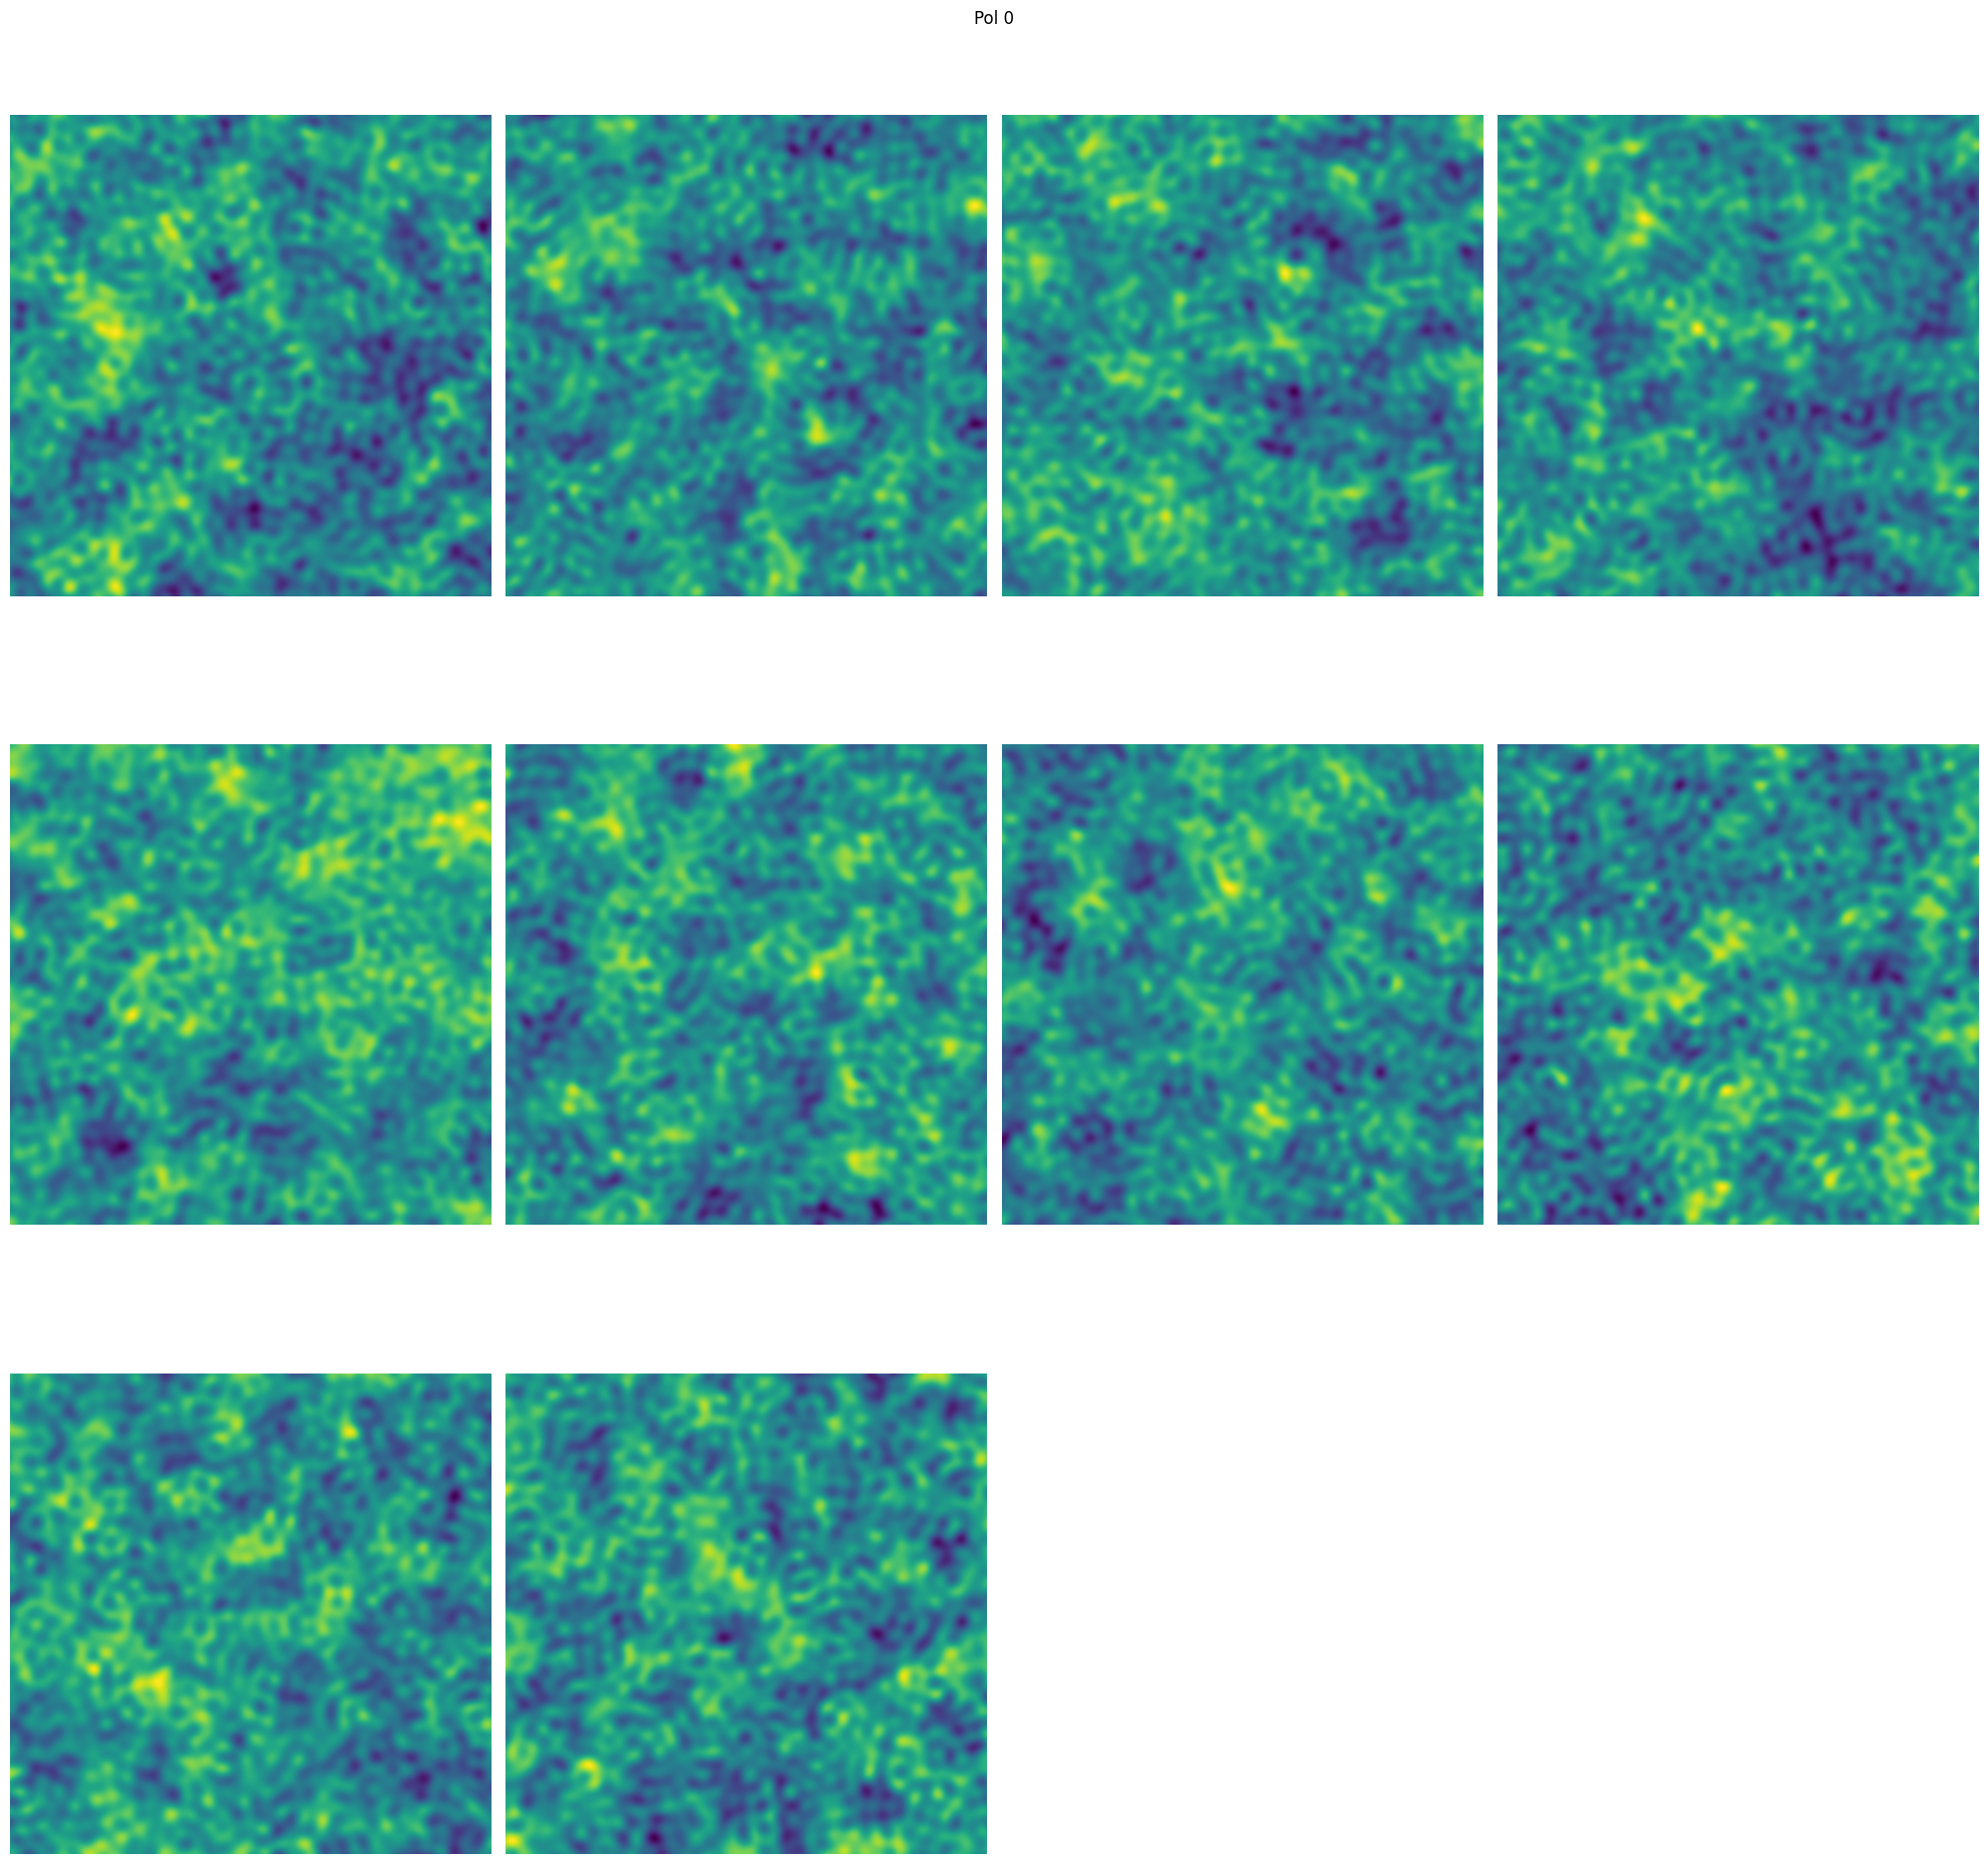

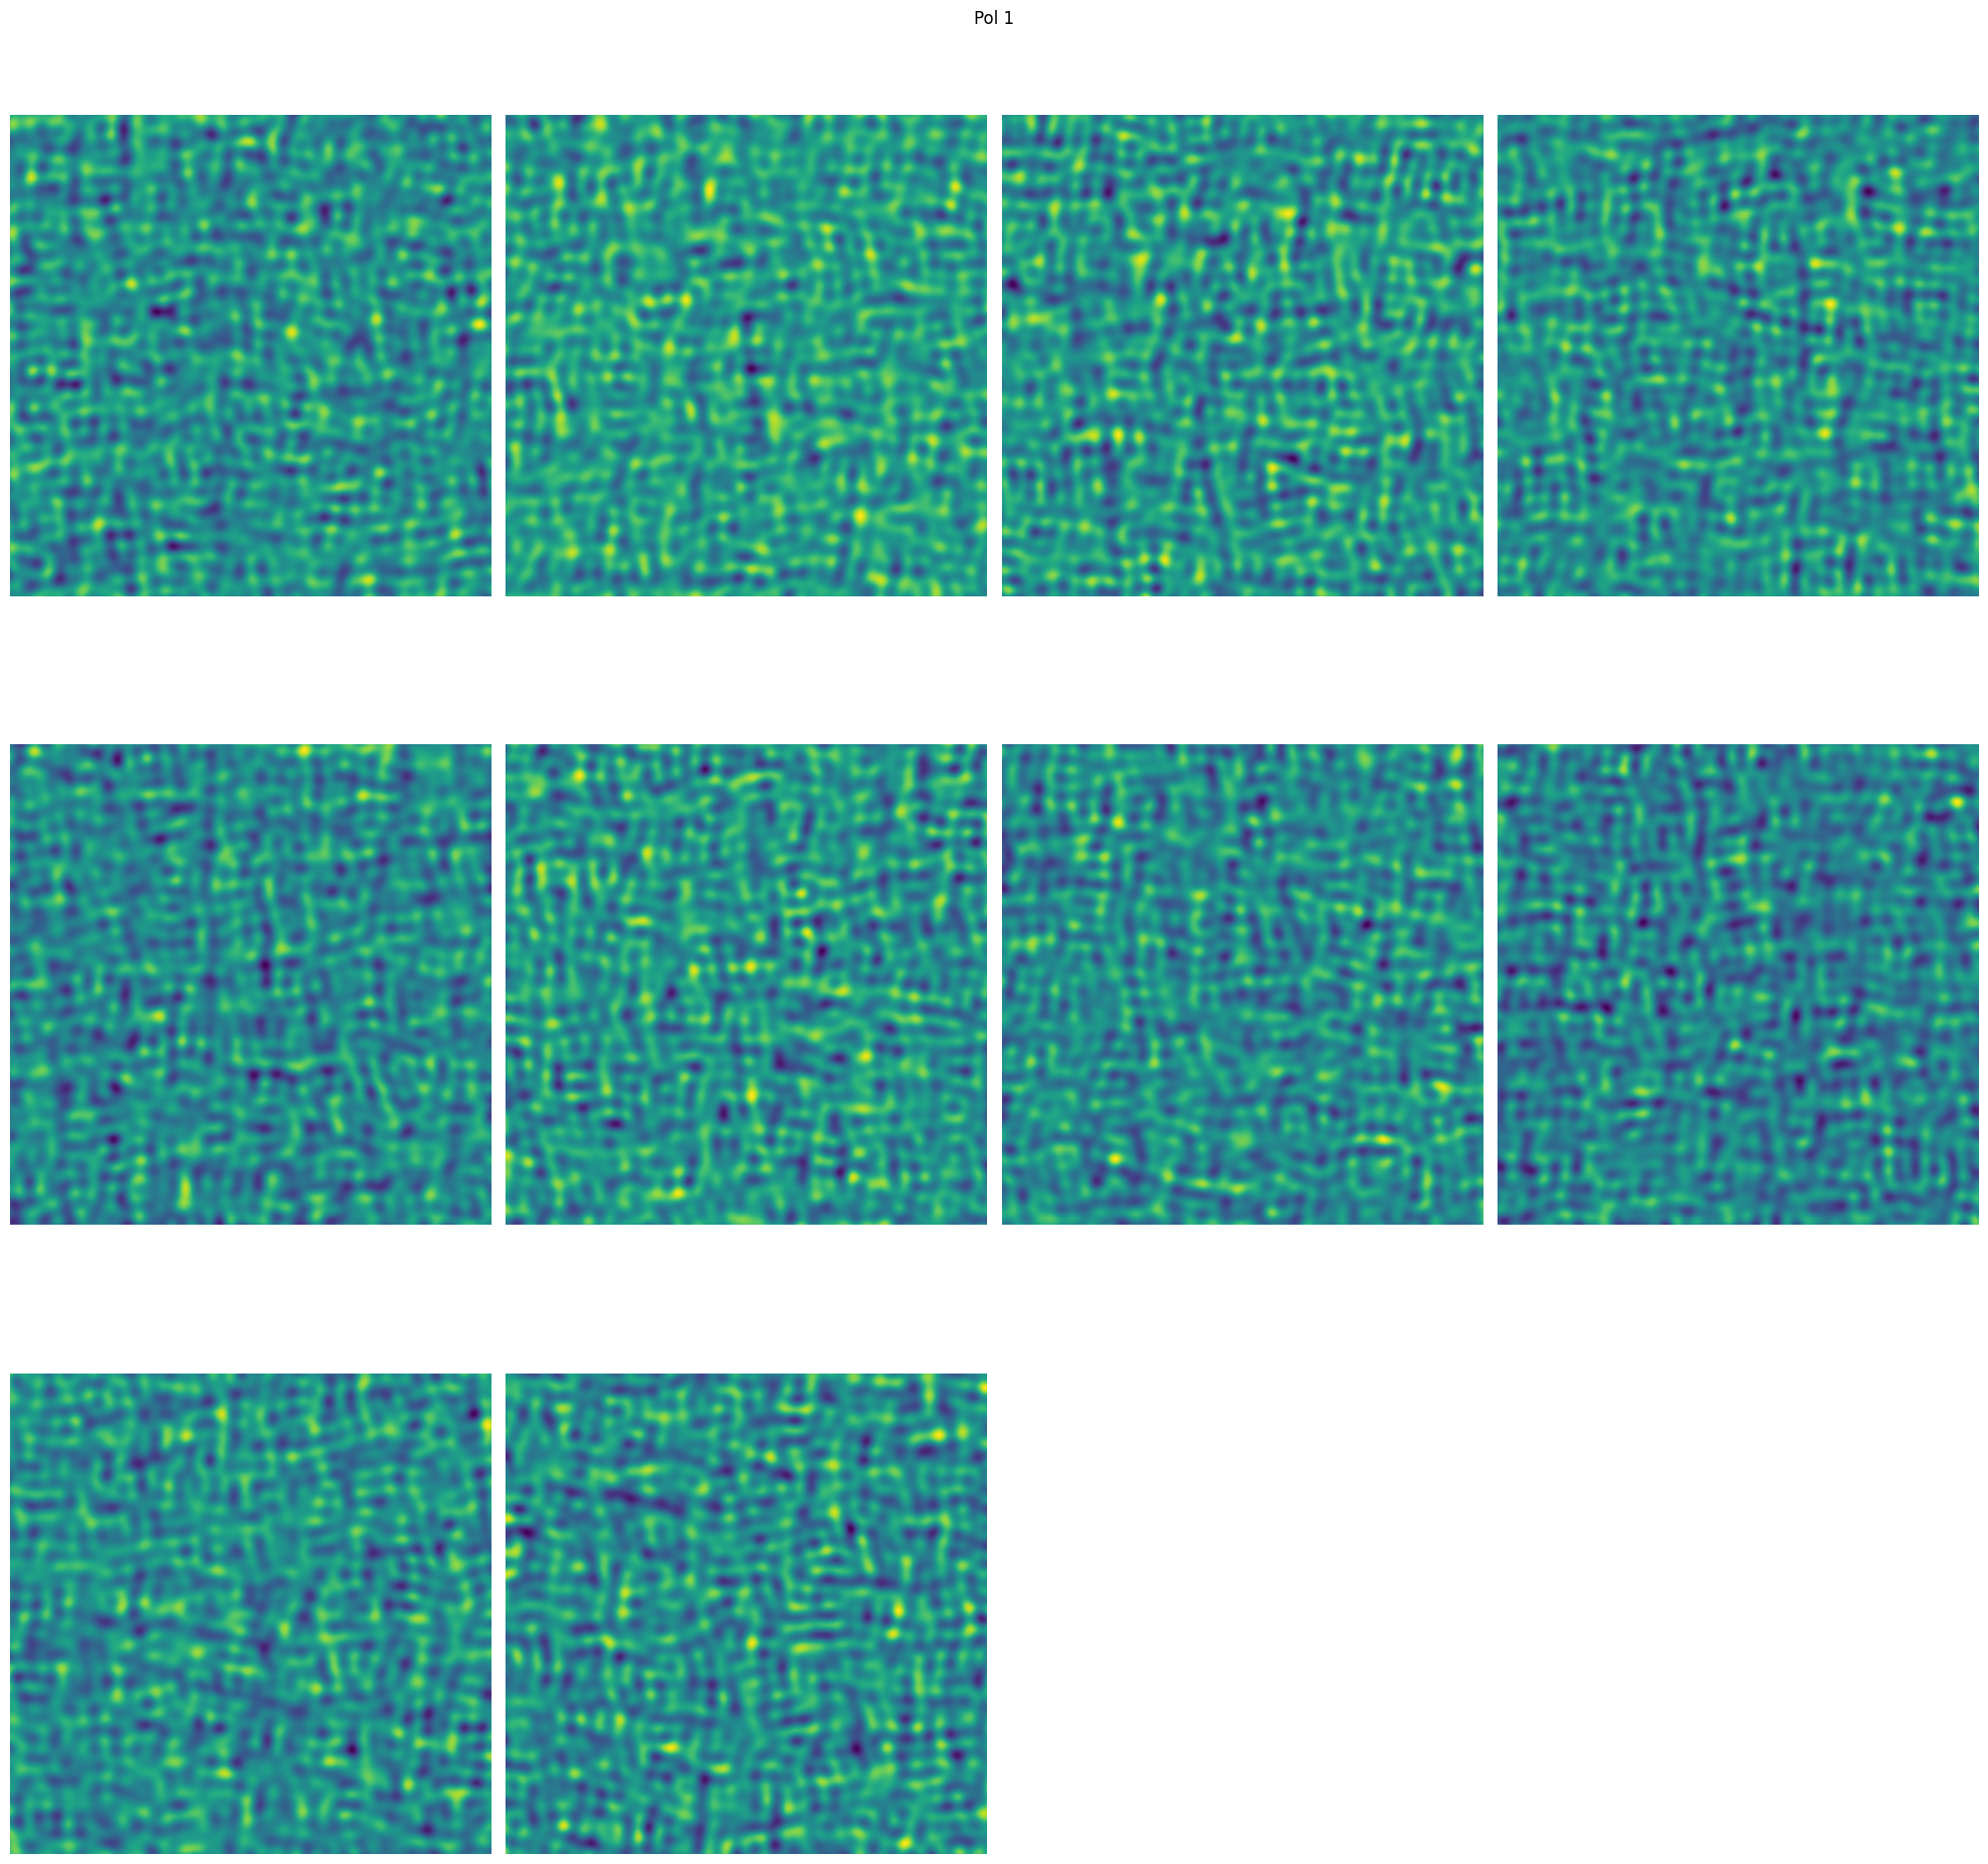

In [ ]:
for pol in range(core.npol):
    plot_patches(patches[0, pol], 10, title=f"Pol {pol}")

## Estimator

In [ ]:
mc_path = os.path.join(core.base_dir, "kswmc")
os.makedirs(mc_path, exist_ok=True)
mc_file = os.path.join(mc_path, f"{core.base_name}.hdf5")

# uncomment to remove the mc file to regenerated
# if os.path.exists(mc_file):
#     os.remove(mc_file)

theta_batch = int(np.floor(1.5 * core.lmax + 1)) // len(os.sched_getaffinity(0))

if os.path.exists(mc_file):
    logger.info("Loading KSW state from %s", mc_file)
    core.ksw.start_from_read_state(mc_file, None)
else:

    def alm_step_loader(idx):
        return core.data.compute_alm_sim(core.lensing)

    core.ksw.step_batch(alm_step_loader, range(10), theta_batch=theta_batch)

    # logger.info("Saving KSW state to %s", mc_file)
    # core.ksw.write_state(mc_file)

24-May-24 16:32:26 - notebooks.ksw_joblib - INFO - processing 0


KeyboardInterrupt: 

In [ ]:
fisher = float(core.ksw.compute_fisher())
logger.info("Fisher: %s, standard deviation: %s", fisher, np.sqrt(1 / fisher))

In [ ]:
print(alms.shape)

In [ ]:
def alm_loader(i):
    logger.info("Loading alm %s, FNL %s", i, fnls[i])
    return alms[i]


print(alms.shape)
idxs = range(alms.shape[0])

estimates = core.ksw.compute_estimate_batch(
    alm_loader, idxs, theta_batch=theta_batch, fisher=fisher
)

In [ ]:
plot_predictions(fnls, estimates, fisher=fisher)